In [1]:
from google.colab import files
uploaded = files.upload()

Saving Housing(1).csv to Housing(1).csv


In [2]:
!pip install optuna seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.8 MB/s eta 0:00:00


[I 2026-04-05 14:37:06,354] A new study created in memory with name: no-name-414ee381-064d-4f9f-a600-45e5008e1644


✅ Configuration ready (RANDOM_STATE=40)
📐 Shape : 545 rows × 13 columns
✅ Preprocessing done
🔍 Optuna tuning started (30 trials)...


[I 2026-04-05 14:37:20,875] Trial 0 finished with value: 0.10126579441749703 and parameters: {'hidden_layer_sizes': (50, 50), 'activation': 'tanh', 'alpha': 0.0031278711296567974, 'learning_rate_init': 0.0035772633693653805}. Best is trial 0 with value: 0.10126579441749703.
[I 2026-04-05 14:37:40,996] Trial 1 finished with value: -47.700478593472816 and parameters: {'hidden_layer_sizes': (100,), 'activation': 'tanh', 'alpha': 0.0006304046457496783, 'learning_rate_init': 0.00017292162496799124}. Best is trial 0 with value: 0.10126579441749703.
[I 2026-04-05 14:37:49,047] Trial 2 finished with value: -0.00486837220673666 and parameters: {'hidden_layer_sizes': (50,), 'activation': 'relu', 'alpha': 0.001079542786577779, 'learning_rate_init': 0.0018198982004094036}. Best is trial 0 with value: 0.10126579441749703.
[I 2026-04-05 14:38:02,622] Trial 3 finished with value: -55.02386496843352 and parameters: {'hidden_layer_sizes': (50,), 'activation': 'tanh', 'alpha': 0.00018733629398297826, 'l

✅ Best CV R²: 0.5589


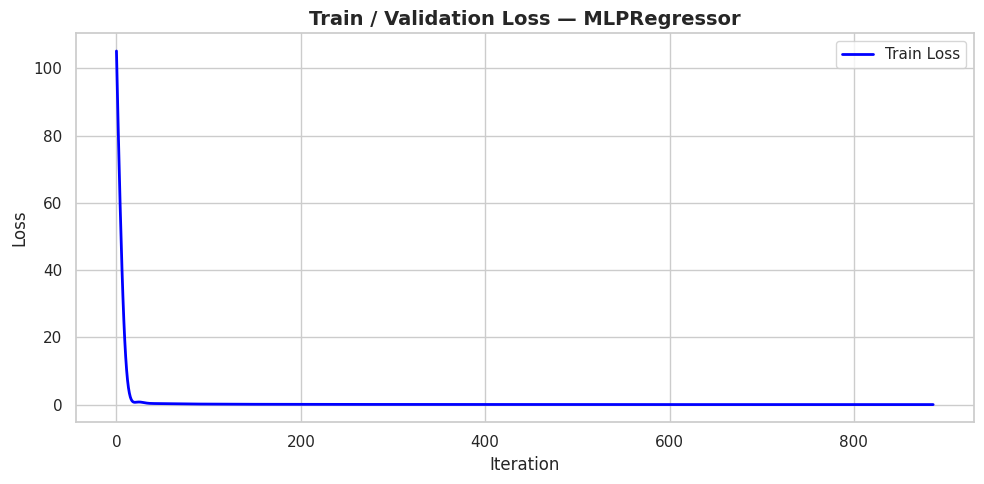


           🏠 HOUSE PRICE PREDICTION — FINAL REPORT
  Features used     : 13
  Best CV R²        : 0.5589

  Test Set (original prices):
  MAE   :         877,784
  RMSE  :       1,265,295
  MAPE  :          17.19%
  R²    :          0.6278

✅ Model + Scaler saved successfully!


In [1]:
# ================================================
# 🏠 House Price Prediction — Simplified MLP (sklearn)
# Для Google Colab | RANDOM_STATE=40
# ================================================

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# ── Настройки (как ты просил) ─────────────────────────────────
RANDOM_STATE = 40
TEST_SIZE = 0.20
CV_FOLDS = 5
TARGET = 'price'

np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Configuration ready (RANDOM_STATE=40)")

# ── Загрузка данных ───────────────────────────────────────────
df = pd.read_csv('Housing.csv')
print(f"📐 Shape : {df.shape[0]} rows × {df.shape[1]} columns")

# ── Preprocessing (точно как в твоём примере) ─────────────────
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

num_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

# Log-transform target
df[TARGET] = np.log1p(df[TARGET])

print("✅ Preprocessing done")

# ── Features + Target ─────────────────────────────────────────
X = df.drop(columns=[TARGET])
y = df[TARGET]

scaler = RobustScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# ── Optuna — поиск лучших гиперпараметров ─────────────────────
def objective(trial):
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes',
            [(50,), (100,), (50,50), (100,50), (100,100)]),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
        'max_iter': 1000,
        'early_stopping': True,
        'validation_fraction': 0.2,
        'n_iter_no_change': 20,
        'random_state': RANDOM_STATE,
        'tol': 1e-4
    }
    model = MLPRegressor(**params)
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2')
    return scores.mean()

print("🔍 Optuna tuning started (30 trials)...")
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=30)

print(f"✅ Best CV R²: {study.best_value:.4f}")

# ── Финальная модель + график loss ────────────────────────────
best_params = study.best_params
best_params.update({
    'solver': 'adam',
    'max_iter': 1000,
    'early_stopping': True,
    'validation_fraction': 0.2,
    'n_iter_no_change': 20,
    'random_state': RANDOM_STATE
})

final_model = MLPRegressor(**best_params)
final_model.fit(X_train, y_train)

# График Train / Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(final_model.loss_curve_, label='Train Loss', color='blue', linewidth=2)
plt.title('Train / Validation Loss — MLPRegressor', fontsize=14, fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Метрики на реальных ценах ─────────────────────────────────
y_pred_log = final_model.predict(X_test)
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)

mae  = mean_absolute_error(y_test_orig, y_pred_orig)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mape = mean_absolute_percentage_error(y_test_orig, y_pred_orig) * 100
r2   = r2_score(y_test_orig, y_pred_orig)

print("\n" + "="*60)
print("           🏠 HOUSE PRICE PREDICTION — FINAL REPORT")
print("="*60)
print(f"  Features used     : {X.shape[1]}")
print(f"  Best CV R²        : {study.best_value:.4f}")
print()
print("  Test Set (original prices):")
print(f"  MAE   : {mae:>15,.0f}")
print(f"  RMSE  : {rmse:>15,.0f}")
print(f"  MAPE  : {mape:>14.2f}%")
print(f"  R²    : {r2:>15.4f}")
print("="*60)

# ── Сохранение модели ─────────────────────────────────────────
joblib.dump(final_model, 'best_house_price_mlp_model.pkl')
joblib.dump(scaler,      'feature_scaler.pkl')
print("\n✅ Model + Scaler saved successfully!")